**DeepCredit_Deep_Learning_Model**

In [ ]:
## 📊 Project Overview

DeepCredit is an Explainable Deep Learning system designed to estimate
the probability of credit card default.

The project uses historical customer financial data to identify patterns
associated with future payment default.

### 🎯 Objective

Build a neural network that can:

1. Predict credit default probability
2. Handle class imbalance
3. Identify important financial risk factors
4. Explain individual predictions using SHAP
5. Simulate how financial changes may affect predicted risk

### 🏦 FinTech Use Case

Credit-risk prediction is an important application of FinTech and
financial analytics. A system such as DeepCredit can support analysts
in identifying potentially higher-risk accounts and understanding the
factors behind model predictions.

> **Disclaimer:** This project is for educational and portfolio purposes.
> It is not intended for real-world lending decisions.

In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import sklearn

# Deep Learning
import tensorflow as tf

# Display versions
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

Pandas: 2.3.3
NumPy: 2.3.5
Scikit-learn: 1.7.2
TensorFlow: 2.21.0


In [6]:
# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
!pip install ucimlrepo

In [8]:
from ucimlrepo import fetch_ucirepo

# Fetch the UCI Credit Card Default dataset
credit_data = fetch_ucirepo(id=350)

# Separate features and target
X = credit_data.data.features
y = credit_data.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30000, 23)
Target shape: (30000, 1)


In [9]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [10]:
print("Columns in the dataset:\n")

for i, column in enumerate(X.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. X1
2. X2
3. X3
4. X4
5. X5
6. X6
7. X7
8. X8
9. X9
10. X10
11. X11
12. X12
13. X13
14. X14
15. X15
16. X16
17. X17
18. X18
19. X19
20. X20
21. X21
22. X22
23. X23


In [11]:
# Rename the features with meaningful names
X.columns = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

print("Columns renamed successfully.")

Columns renamed successfully.


In [12]:
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [13]:
print(y.columns)
print("\nTarget distribution:")
print(y.iloc[:, 0].value_counts())

Index(['Y'], dtype='object')

Target distribution:
Y
0    23364
1     6636
Name: count, dtype: int64


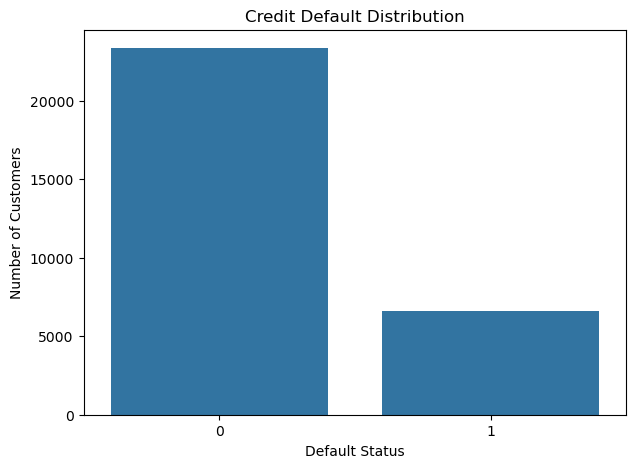

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y.iloc[:, 0])

plt.title("Credit Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
# Calculate default rate for each repayment-status category

default_by_pay = (
    pd.DataFrame({
        "PAY_0": X["PAY_0"],
        "Default": y.iloc[:, 0]
    })
    .groupby("PAY_0")["Default"]
    .agg(["count", "mean"])
)

# Convert mean into percentage
default_by_pay["default_rate_%"] = default_by_pay["mean"] * 100

default_by_pay

,count,mean,default_rate_%
PAY_0,,,
-2,2759,0.132294,13.229431
-1,5686,0.167781,16.778051
0,14737,0.128113,12.811291
1,3688,0.339479,33.947939
2,2667,0.691414,69.141357
3,322,0.757764,75.776398
4,76,0.684211,68.421053
5,26,0.500000,50.000000
6,11,0.545455,54.545455


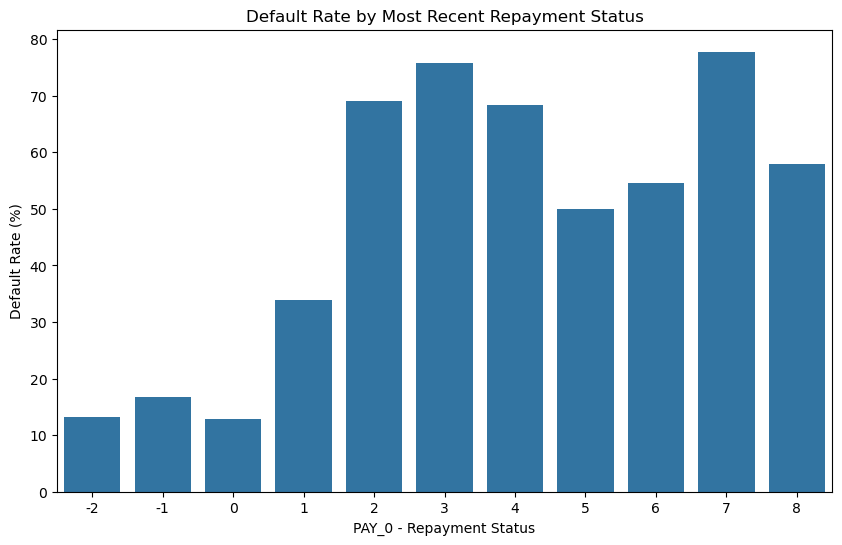

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=default_by_pay.index,
    y=default_by_pay["default_rate_%"]
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0 - Repayment Status")
plt.ylabel("Default Rate (%)")

plt.show()

In [18]:
# Compare average credit limit for defaulters and non-defaulters

credit_limit_analysis = (
    pd.DataFrame({
        "LIMIT_BAL": X["LIMIT_BAL"],
        "Default": y.iloc[:, 0]
    })
    .groupby("Default")["LIMIT_BAL"]
    .agg(["mean", "median", "min", "max"])
)

credit_limit_analysis

,mean,median,min,max
Default,,,,
0,178099.726074,150000.0,10000,1000000
1,130109.656420,90000.0,10000,740000


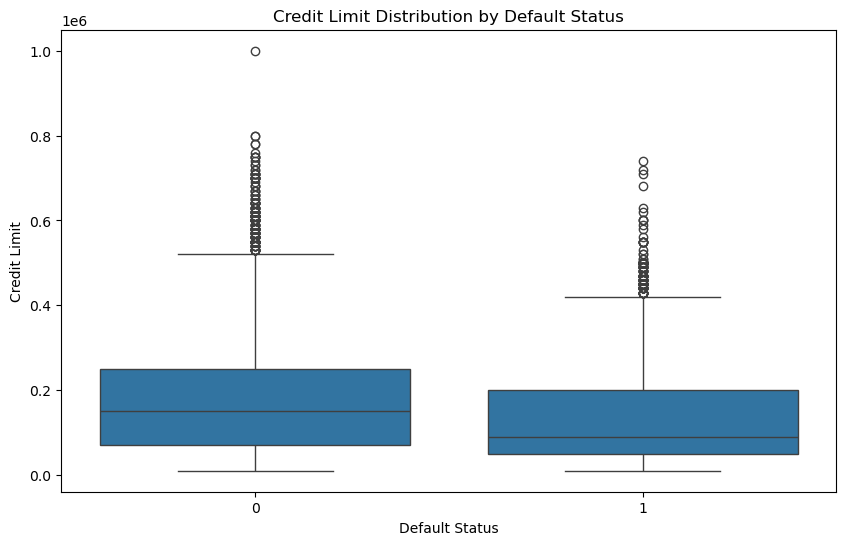

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=y.iloc[:, 0],
    y=X["LIMIT_BAL"]
)

plt.title("Credit Limit Distribution by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Credit Limit")

plt.show()

In [20]:
X["AVG_PAYMENT"] = X[
    ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
     "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
].mean(axis=1)

print(X["AVG_PAYMENT"].describe())

count     30000.000000
mean       5275.232094
std       10137.946323
min           0.000000
25%        1113.291667
50%        2397.166667
75%        5583.916667
max      627344.333333
Name: AVG_PAYMENT, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_20424\2589704294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["AVG_PAYMENT"] = X[


In [21]:
payment_analysis = (
    pd.DataFrame({
        "AVG_PAYMENT": X["AVG_PAYMENT"],
        "Default": y.iloc[:, 0]
    })
    .groupby("Default")["AVG_PAYMENT"]
    .agg(["mean", "median"])
)

payment_analysis

,mean,median
Default,,
0,5828.236775,2754.000000
1,3328.215617,1612.416667


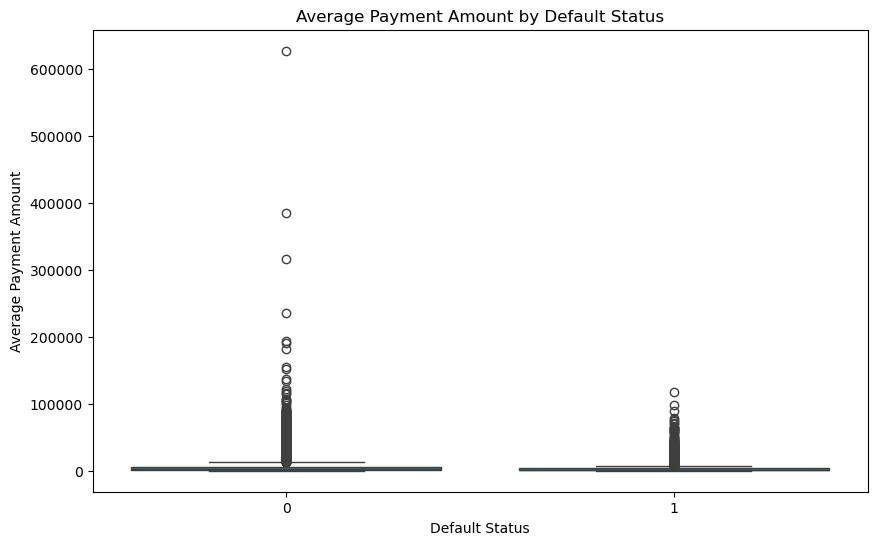

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=y.iloc[:, 0],
    y=X["AVG_PAYMENT"]
)

plt.title("Average Payment Amount by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Average Payment Amount")

plt.show()

In [23]:
# Average bill amount over the six observed months

X["AVG_BILL"] = X[
    ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
     "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
].mean(axis=1)

print(X["AVG_BILL"].describe())

count     30000.000000
mean      44976.945200
std       63260.721860
min      -56043.166667
25%        4781.333333
50%       21051.833333
75%       57104.416667
max      877313.833333
Name: AVG_BILL, dtype: float64


In [24]:
# Credit utilization = average bill / credit limit

X["CREDIT_UTILIZATION"] = (
    X["AVG_BILL"] / X["LIMIT_BAL"]
)

# Replace any infinite values
X["CREDIT_UTILIZATION"] = (
    X["CREDIT_UTILIZATION"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(X["CREDIT_UTILIZATION"].describe())

count    30000.000000
mean         0.373048
std          0.351890
min         -0.232590
25%          0.029997
50%          0.284834
75%          0.687929
max          5.364308
Name: CREDIT_UTILIZATION, dtype: float64


In [26]:
# Total payments over the six months
X["TOTAL_PAYMENT"] = X[
    ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
     "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
].sum(axis=1)

# Total bills over the six months
X["TOTAL_BILL"] = X[
    ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
     "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
].sum(axis=1)

# Payment-to-bill ratio
X["PAYMENT_BILL_RATIO"] = (
    X["TOTAL_PAYMENT"] / X["TOTAL_BILL"].replace(0, np.nan)
)

X["PAYMENT_BILL_RATIO"] = (
    X["PAYMENT_BILL_RATIO"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(X["PAYMENT_BILL_RATIO"].describe())

count    30000.000000
mean         0.380941
std          7.671004
min       -546.928571
25%          0.040952
50%          0.084932
75%          0.586922
max        797.000000
Name: PAYMENT_BILL_RATIO, dtype: float64


In [27]:
# Count how many of the six months show a positive repayment delay

payment_status_cols = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

X["DELAYED_MONTHS"] = (
    X[payment_status_cols] > 0
).sum(axis=1)

print(X["DELAYED_MONTHS"].value_counts().sort_index())

DELAYED_MONTHS
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64


In [28]:
# Maximum observed repayment delay

X["MAX_DELAY"] = X[payment_status_cols].max(axis=1)

print(X["MAX_DELAY"].value_counts().sort_index())

MAX_DELAY
-2     2109
-1     3086
 0    14736
 1     1689
 2     7187
 3      789
 4      218
 5       69
 6       25
 7       67
 8       25
Name: count, dtype: int64


In [29]:
# Average repayment status across the six observed months

X["AVG_DELAY"] = X[payment_status_cols].mean(axis=1)

print(X["AVG_DELAY"].describe())

count    30000.000000
mean        -0.182439
std          0.982176
min         -2.000000
25%         -0.833333
50%          0.000000
75%          0.000000
max          6.000000
Name: AVG_DELAY, dtype: float64


In [30]:
risk_features = [
    "LIMIT_BAL",
    "AVG_BILL",
    "AVG_PAYMENT",
    "CREDIT_UTILIZATION",
    "PAYMENT_BILL_RATIO",
    "DELAYED_MONTHS",
    "MAX_DELAY",
    "AVG_DELAY"
]

X[risk_features].head(10)

,LIMIT_BAL,AVG_BILL,AVG_PAYMENT,CREDIT_UTILIZATION,PAYMENT_BILL_RATIO,DELAYED_MONTHS,MAX_DELAY,AVG_DELAY
0,20000,1284.000000,114.833333,0.064200,0.089434,2,2,-0.333333
1,120000,2846.166667,833.333333,0.023718,0.292791,2,2,0.500000
2,90000,16942.166667,1836.333333,0.188246,0.108388,0,0,0.000000
3,50000,38555.666667,1398.000000,0.771113,0.036259,0,0,0.000000
4,50000,18223.166667,9841.500000,0.364463,0.540054,0,0,-0.333333
5,50000,39685.666667,1295.333333,0.793713,0.032640,0,0,0.000000
6,500000,454099.166667,30126.500000,0.908198,0.066343,0,0,0.000000
7,100000,2247.666667,798.500000,0.022477,0.355257,0,0,-0.500000
8,140000,10868.666667,1126.833333,0.077633,0.103677,1,2,0.333333
9,20000,4486.500000,2354.833333,0.224325,0.524871,0,-1,-1.666667


In [31]:
# Combine engineered features with the target

analysis_df = X[risk_features].copy()
analysis_df["DEFAULT"] = y.iloc[:, 0].values

# Correlation with default
correlation = (
    analysis_df.corr()["DEFAULT"]
    .sort_values(ascending=False)
)

correlation

DEFAULT               1.000000
DELAYED_MONTHS        0.398394
MAX_DELAY             0.331036
AVG_DELAY             0.281955
CREDIT_UTILIZATION    0.115483
PAYMENT_BILL_RATIO   -0.011657
AVG_BILL             -0.012691
AVG_PAYMENT          -0.102354
LIMIT_BAL            -0.153520
Name: DEFAULT, dtype: float64

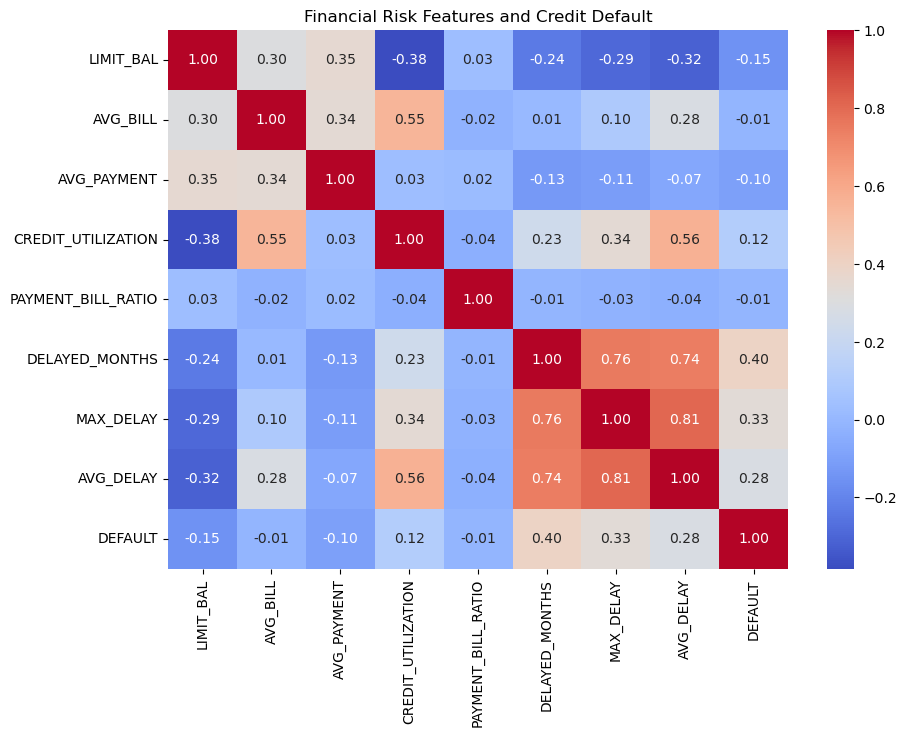

In [32]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    analysis_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Financial Risk Features and Credit Default")

plt.show()

In [33]:
print("Number of features:", X.shape[1])
print("\nFeature names:")
print(X.columns.tolist())

Number of features: 32

Feature names:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_PAYMENT', 'AVG_BILL', 'CREDIT_UTILIZATION', 'TOTAL_PAYMENT', 'TOTAL_BILL', 'PAYMENT_BILL_RATIO', 'DELAYED_MONTHS', 'MAX_DELAY', 'AVG_DELAY']


In [34]:
if "ID" in X.columns:
    X = X.drop(columns=["ID"])
    print("ID column removed.")
else:
    print("No ID column found.")

No ID column found.


In [35]:
y_final = y.iloc[:, 0].astype(int).values

print("Target shape:", y_final.shape)
print("Unique target values:", np.unique(y_final))

Target shape: (30000,)
Unique target values: [0 1]


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 24000
Testing samples: 6000


In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (24000, 32)
Testing data shape: (6000, 32)


In [38]:
scaler.fit_transform(X_train)

array([[-0.05686623,  0.80844039,  0.18452304, ...,  2.04043134,
         1.91112339,  1.72133328],
       [-0.13408117,  0.80844039, -1.07753249, ...,  0.10594025,
         0.41766932, -1.00549757],
       [-1.21509034, -1.23694958,  0.18452304, ...,  0.75077061,
         1.16439636,  0.69877171],
       ...,
       [-0.36572599,  0.80844039, -1.07753249, ..., -0.53889011,
        -0.32905771,  0.18749092],
       [ 1.48743258, -1.23694958, -1.07753249, ...,  0.10594025,
         0.41766932, -0.83507064],
       [ 1.02414294, -1.23694958, -1.07753249, ..., -0.53889011,
        -1.07578475, -1.1759245 ]], shape=(24000, 32))

In [39]:
scaler.transform(X_test)

array([[-0.90623058, -1.23694958,  0.18452304, ..., -0.53889011,
        -0.32905771, -0.49421679],
       [-0.13408117, -1.23694958, -1.07753249, ..., -0.53889011,
        -1.07578475, -1.34635143],
       [-0.90623058, -1.23694958,  0.18452304, ..., -0.53889011,
        -0.32905771,  0.18749092],
       ...,
       [ 0.40642341, -1.23694958, -1.07753249, ..., -0.53889011,
        -0.32905771, -0.32378986],
       [-0.36572599, -1.23694958, -1.07753249, ..., -0.53889011,
        -1.07578475, -1.00549757],
       [ 0.25199353, -1.23694958,  1.44657857, ..., -0.53889011,
        -1.07578475, -1.51677836]], shape=(6000, 32))

In [40]:
print("NaN values in training data:", np.isnan(X_train_scaled).sum())
print("Infinite values in training data:", np.isinf(X_train_scaled).sum())

print("NaN values in test data:", np.isnan(X_test_scaled).sum())
print("Infinite values in test data:", np.isinf(X_test_scaled).sum())

NaN values in training data: 0
Infinite values in training data: 0
NaN values in test data: 0
Infinite values in test data: 0


In [41]:
# Build the DeepCredit Neural Network

model = Sequential([
    
    # Input + first hidden layer
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    
    # Prevent overfitting
    Dropout(0.30),
    
    # Second hidden layer
    Dense(64, activation="relu"),
    
    # Prevent overfitting
    Dropout(0.20),
    
    # Third hidden layer
    Dense(32, activation="relu"),
    
    # Output layer
    Dense(1, activation="sigmoid")
])

# Display model architecture
model.summary()

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
Dense(128, activation="relu")

<Dense name=dense_4, built=False>

In [44]:
Dropout(0.30)

<Dropout name=dropout_2, built=True>

In [45]:
Dense(1, activation="sigmoid")

<Dense name=dense_5, built=False>

In [46]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("DeepCredit model compiled successfully.")

DeepCredit model compiled successfully.


In [47]:
optimizer="adam"

In [48]:
loss="binary_crossentropy"

In [49]:
# Early stopping prevents unnecessary training
early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7986 - auc: 0.7061 - loss: 0.4803 - precision: 0.5799 - recall: 0.2837 - val_accuracy: 0.8081 - val_auc: 0.7612 - val_loss: 0.4579 - val_precision: 0.6209 - val_recall: 0.4466
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8125 - auc: 0.7501 - loss: 0.4488 - precision: 0.6249 - recall: 0.3543 - val_accuracy: 0.8104 - val_auc: 0.7717 - val_loss: 0.4495 - val_precision: 0.6398 - val_recall: 0.4206
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8154 - auc: 0.7620 - loss: 0.4420 - precision: 0.6324 - recall: 0.3696 - val_accuracy: 0.8112 - val_auc: 0.7750 - val_loss: 0.4462 - val_precision: 0.6615 - val_recall: 0.3839
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8183 - auc: 0.7699 - loss: 0.4364 - precision: 0.6467 - recall: 0.3705 - val_accuracy: 0.8112 - val_auc: 0.7768 - val_loss: 0.4457 - val_precision: 0.6883 - val_recall: 0.3426
Epoch 5/50
300/300 ━━━━━━━━━━━━━

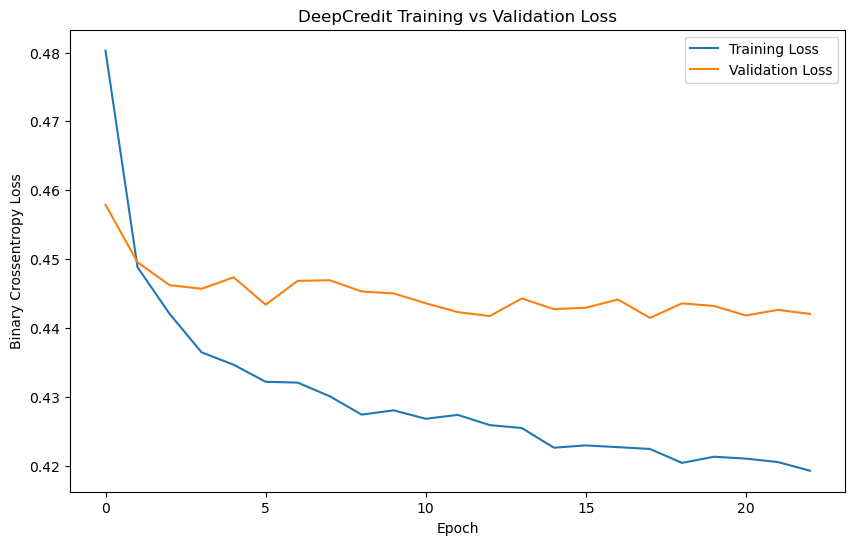

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("DeepCredit Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()

plt.show()

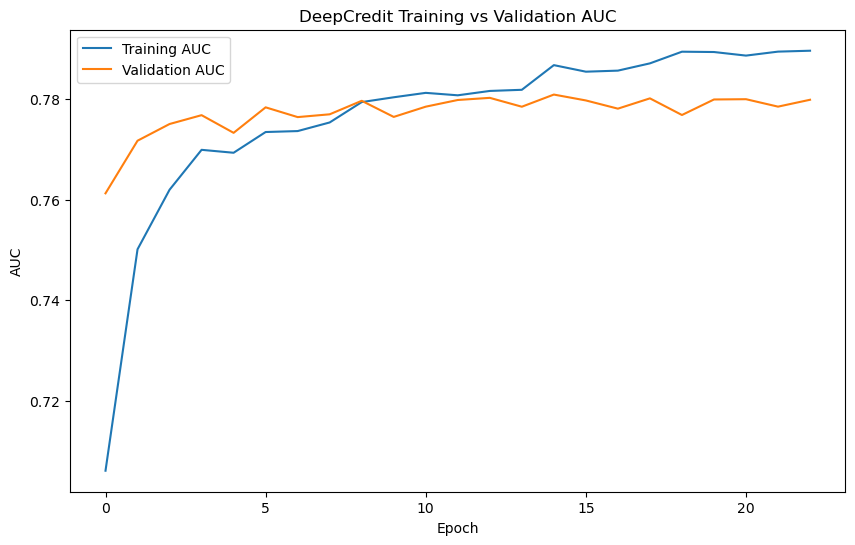

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["auc"], label="Training AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")

plt.title("DeepCredit Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()

plt.show()

In [52]:
# Evaluate DeepCredit on unseen test data

test_results = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss      :", round(test_results[0], 4))
print("Test Accuracy  :", round(test_results[1], 4))
print("Test AUC       :", round(test_results[2], 4))
print("Test Precision :", round(test_results[3], 4))
print("Test Recall    :", round(test_results[4], 4))

Test Loss      : 0.4343
Test Accuracy  : 0.8175
Test AUC       : 0.772
Test Precision : 0.6796
Test Recall    : 0.3308


In [53]:
# Generate default probabilities for the test customers

y_probability = model.predict(
    X_test_scaled,
    verbose=0
).ravel()

print("First 10 predicted probabilities:")
print(np.round(y_probability[:10], 4))

First 10 predicted probabilities:
[0.1118 0.1281 0.2013 0.1768 0.0573 0.25   0.1189 0.0288 0.0909 0.0905]


In [54]:
Dense(1, activation="sigmoid")

<Dense name=dense_6, built=False>

In [55]:
# Convert probabilities into binary predictions

threshold = 0.50

y_pred = (y_probability >= threshold).astype(int)

print("Number predicted as non-default:", (y_pred == 0).sum())
print("Number predicted as default:", (y_pred == 1).sum())

Number predicted as non-default: 5354
Number predicted as default: 646


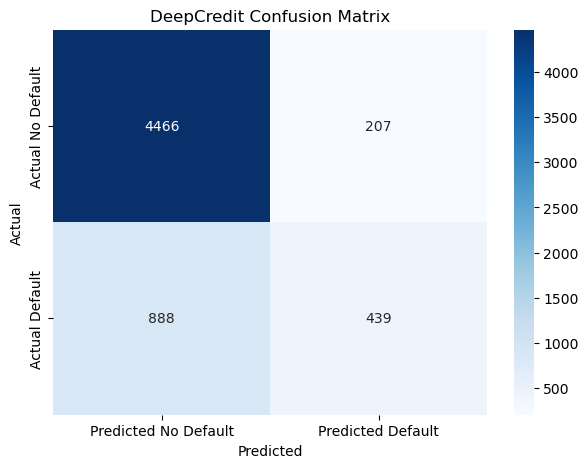

In [56]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Default", "Predicted Default"],
    yticklabels=["Actual No Default", "Actual Default"]
)

plt.title("DeepCredit Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [57]:
print("DeepCredit Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Default", "Default"]
    )
)

DeepCredit Classification Report

              precision    recall  f1-score   support

  No Default       0.83      0.96      0.89      4673
     Default       0.68      0.33      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



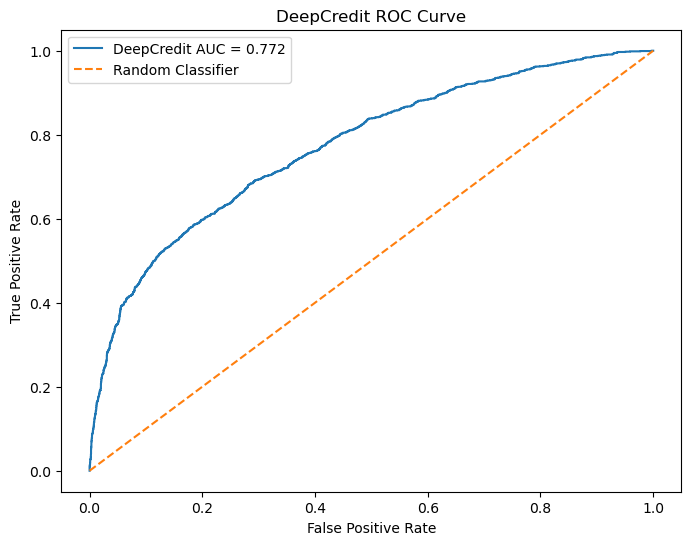

In [58]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"DeepCredit AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("DeepCredit ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [59]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate balanced class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

Class weights:
{np.int64(0): np.float64(0.6420202236370446), np.int64(1): np.float64(2.2603126765869277)}


In [60]:
# Improved DeepCredit Neural Network

model_weighted = Sequential([
    
    Dense(
        128,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),
    
    Dropout(0.30),
    
    Dense(64, activation="relu"),
    
    Dropout(0.20),
    
    Dense(32, activation="relu"),
    
    Dense(1, activation="sigmoid")
])

model_weighted.summary()

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model_weighted.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Weighted DeepCredit model compiled successfully.")

Weighted DeepCredit model compiled successfully.


In [62]:
early_stopping_weighted = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    restore_best_weights=True
)

history_weighted = model_weighted.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping_weighted],
    verbose=1
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7290 - auc: 0.7358 - loss: 0.6002 - precision: 0.4170 - recall: 0.6042 - val_accuracy: 0.7379 - val_auc: 0.7676 - val_loss: 0.6017 - val_precision: 0.4551 - val_recall: 0.6493
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7506 - auc: 0.7567 - loss: 0.5808 - precision: 0.4479 - recall: 0.6090 - val_accuracy: 0.7706 - val_auc: 0.7749 - val_loss: 0.5672 - val_precision: 0.5053 - val_recall: 0.5937
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7556 - auc: 0.7640 - loss: 0.5757 - precision: 0.4559 - recall: 0.6154 - val_accuracy: 0.7735 - val_auc: 0.7768 - val_loss: 0.5559 - val_precision: 0.5110 - val_recall: 0.5839
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7545 - auc: 0.7730 - loss: 0.5666 - precision: 0.4552 - recall: 0.6290 - val_accuracy: 0.7535 - val_auc: 0.7776 - val_loss: 0.5625 - val_precision: 0.4770 - val_recall: 0.6332
Epoch 5/50
300/300 ━━━━━━━━━━━━━

In [63]:
weighted_results = model_weighted.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Weighted DeepCredit Results")
print("--------------------------------")
print("Test Loss      :", round(weighted_results[0], 4))
print("Test Accuracy  :", round(weighted_results[1], 4))
print("Test AUC       :", round(weighted_results[2], 4))
print("Test Precision :", round(weighted_results[3], 4))
print("Test Recall    :", round(weighted_results[4], 4))

Weighted DeepCredit Results
--------------------------------
Test Loss      : 0.5583
Test Accuracy  : 0.7523
Test AUC       : 0.7689
Test Precision : 0.4548
Test Recall    : 0.6021


In [64]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AUC",
        "Precision",
        "Recall"
    ],
    
    "Baseline": [
        test_results[1],
        test_results[2],
        test_results[3],
        test_results[4]
    ],
    
    "Class Weighted": [
        weighted_results[1],
        weighted_results[2],
        weighted_results[3],
        weighted_results[4]
    ]
})

comparison

,Metric,Baseline,Class Weighted
0,Accuracy,0.817500,0.752333
1,AUC,0.771979,0.768947
2,Precision,0.679567,0.454752
3,Recall,0.330821,0.602110


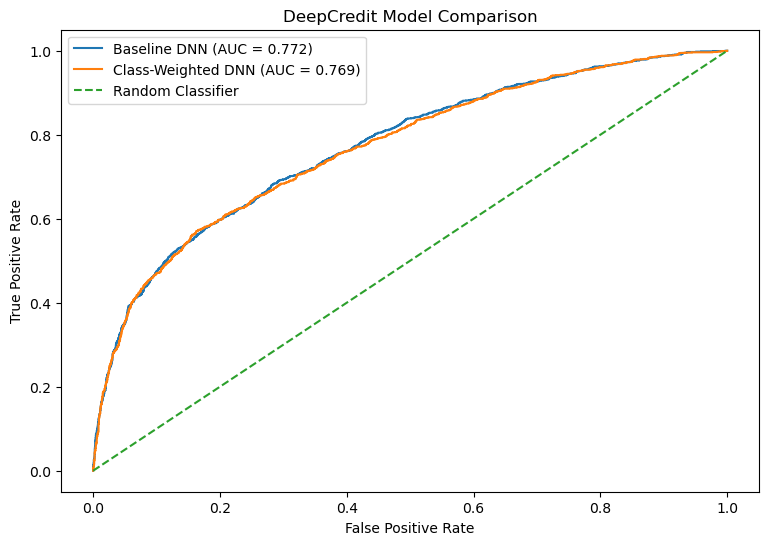

In [65]:
# Baseline probabilities
y_probability_baseline = model.predict(
    X_test_scaled,
    verbose=0
).ravel()

# Weighted model probabilities
y_probability_weighted = model_weighted.predict(
    X_test_scaled,
    verbose=0
).ravel()

# ROC curves
fpr_base, tpr_base, _ = roc_curve(
    y_test,
    y_probability_baseline
)

fpr_weight, tpr_weight, _ = roc_curve(
    y_test,
    y_probability_weighted
)

auc_base = roc_auc_score(
    y_test,
    y_probability_baseline
)

auc_weight = roc_auc_score(
    y_test,
    y_probability_weighted
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Baseline DNN (AUC = {auc_base:.3f})"
)

plt.plot(
    fpr_weight,
    tpr_weight,
    label=f"Class-Weighted DNN (AUC = {auc_weight:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("DeepCredit Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [66]:
# Generate probabilities from the improved model

y_probability_final = model_weighted.predict(
    X_test_scaled,
    verbose=0
).ravel()

print("First 10 predicted probabilities:")
print(np.round(y_probability_final[:10], 4))

First 10 predicted probabilities:
[0.3436 0.3865 0.4201 0.3585 0.1686 0.4352 0.2801 0.1018 0.2752 0.2765]


In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    
    predictions = (
        y_probability_final >= threshold
    ).astype(int)
    
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    threshold_results.append([
        round(threshold, 2),
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.227226,0.996232,0.370049
1,0.15,0.237543,0.987943,0.382997
2,0.20,0.247835,0.970610,0.394850
3,0.25,0.260978,0.949510,0.409423
4,0.30,0.279510,0.911831,0.427864
5,0.35,0.302240,0.864356,0.447872
6,0.40,0.336662,0.787491,0.471677
7,0.45,0.391548,0.684250,0.498080
8,0.50,0.454752,0.602110,0.518158
9,0.55,0.499667,0.565185,0.530410


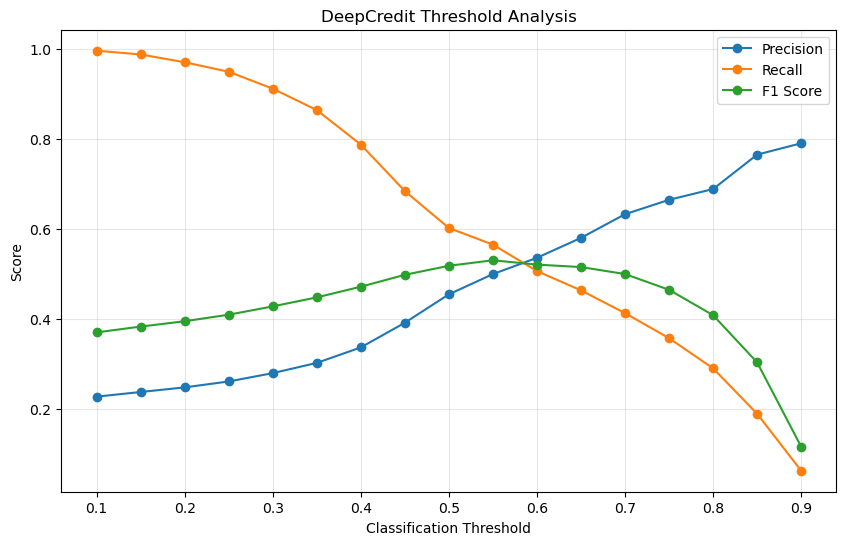

In [68]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.title("DeepCredit Threshold Analysis")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [69]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best threshold based on F1:")
print("Threshold :", best_threshold)
print("Precision :", round(best_row["Precision"], 4))
print("Recall    :", round(best_row["Recall"], 4))
print("F1 Score  :", round(best_row["F1"], 4))

Best threshold based on F1:
Threshold : 0.55
Precision : 0.4997
Recall    : 0.5652
F1 Score  : 0.5304


In [70]:
def risk_category(probability):
    
    if probability < 0.30:
        return "LOW"
    
    elif probability < 0.60:
        return "MEDIUM"
    
    else:
        return "HIGH"


# Test the function
test_probabilities = [0.12, 0.45, 0.78]

for probability in test_probabilities:
    print(
        probability,
        "→",
        risk_category(probability)
    )

0.12 → LOW
0.45 → MEDIUM
0.78 → HIGH


In [71]:
def predict_credit_risk(customer_data):
    
    # Convert input to DataFrame
    customer_df = pd.DataFrame(
        [customer_data],
        columns=X.columns
    )
    
    # Scale using the scaler trained earlier
    customer_scaled = scaler.transform(customer_df)
    
    # Generate probability
    probability = model_weighted.predict(
        customer_scaled,
        verbose=0
    )[0][0]
    
    # Determine risk category
    category = risk_category(probability)
    
    return probability, category

In [72]:
%pip install shap


   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ----

In [73]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [74]:
# Use a small background sample for SHAP
background = X_train_scaled[:100]

# Create SHAP explainer
explainer = shap.KernelExplainer(
    model_weighted.predict,
    background
)

print("SHAP explainer created successfully.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
SHAP explainer created successfully.


In [77]:
# Use a small background sample to make SHAP faster
background = X_train_scaled[:50]

explainer = shap.KernelExplainer(
    model_weighted.predict,
    background
)

print("SHAP explainer created successfully.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step
SHAP explainer created successfully.


In [79]:
# Explain only 10 customers
X_explain = X_test_scaled[:10]

shap_values = explainer.shap_values(
    X_explain,
    nsamples=50
)

print("SHAP explanation completed.")

  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
SHAP explanation completed.


In [80]:
# Check the SHAP output shape
shap_array = np.asarray(shap_values)

print("SHAP output shape:", shap_array.shape)

SHAP output shape: (10, 32, 1)


In [81]:
# Convert SHAP values into a consistent format
if isinstance(shap_values, list):
    shap_array = np.asarray(shap_values[0])
else:
    shap_array = np.asarray(shap_values)

# Handle newer SHAP output format
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 0]

print("Final SHAP shape:", shap_array.shape)
print("Number of features:", len(X.columns))

Final SHAP shape: (10, 32)
Number of features: 32


In [82]:
# Calculate average SHAP importance for each feature
mean_shap = np.abs(shap_array).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP": mean_shap
}).sort_values(
    "Mean_SHAP",
    ascending=False
)

feature_importance.head(15)

,Feature,Mean_SHAP
29,DELAYED_MONTHS,0.056920
5,PAY_0,0.036854
30,MAX_DELAY,0.033465
0,LIMIT_BAL,0.020031
26,TOTAL_PAYMENT,0.016445
25,CREDIT_UTILIZATION,0.016269
12,BILL_AMT2,0.012465
11,BILL_AMT1,0.011290
10,PAY_6,0.010388
15,BILL_AMT5,0.009499


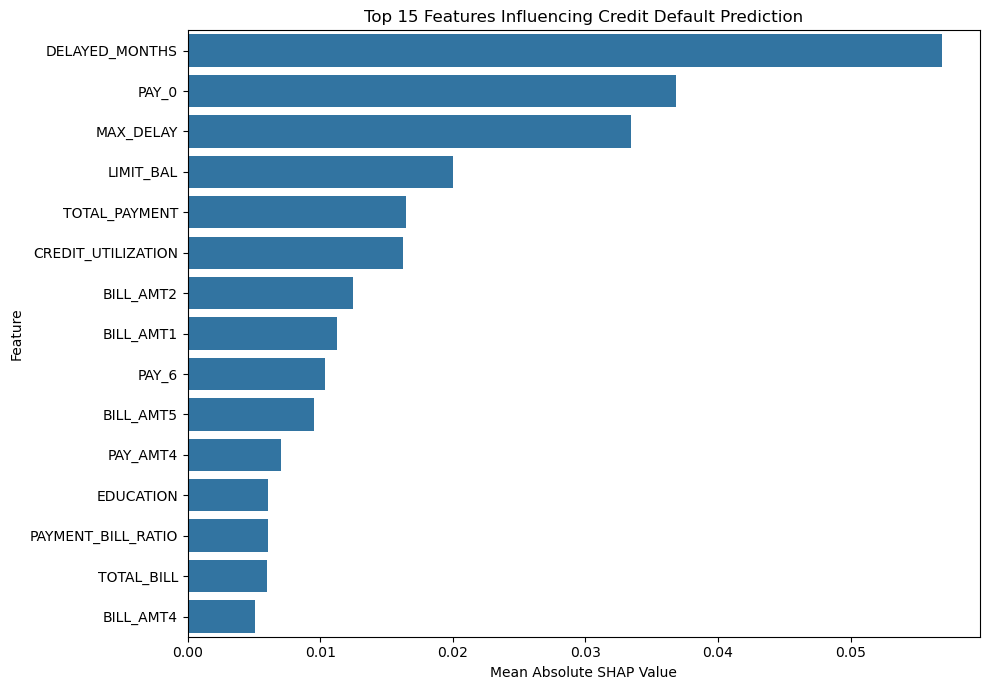

In [83]:
# Plot the top 15 features influencing the model

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Mean_SHAP",
    y="Feature"
)

plt.title("Top 15 Features Influencing Credit Default Prediction")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [84]:
# Select the first test customer
customer_index = 0

customer_probability = y_probability_final[customer_index]

print("Predicted Default Probability:",
      round(customer_probability * 100, 2), "%")

Predicted Default Probability: 34.36 %


In [85]:
# Explain the selected customer's prediction

single_customer_shap = shap_array[customer_index]

customer_explanation = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_Value": single_customer_shap,
    "Feature_Value": X_test.iloc[customer_index].values
})

customer_explanation["Impact"] = np.where(
    customer_explanation["SHAP_Value"] > 0,
    "Increases Default Risk",
    "Decreases Default Risk"
)

customer_explanation = customer_explanation.sort_values(
    "SHAP_Value",
    key=np.abs,
    ascending=False
)

customer_explanation.head(15)

,Feature,SHAP_Value,Feature_Value,Impact
5,PAY_0,-0.040708,-1.000000,Decreases Default Risk
29,DELAYED_MONTHS,-0.026902,0.000000,Decreases Default Risk
2,EDUCATION,-0.020909,2.000000,Decreases Default Risk
30,MAX_DELAY,-0.019214,0.000000,Decreases Default Risk
23,AVG_PAYMENT,-0.018198,6076.166667,Decreases Default Risk
16,BILL_AMT6,-0.012007,2764.000000,Decreases Default Risk
26,TOTAL_PAYMENT,-0.010341,36457.000000,Decreases Default Risk
11,BILL_AMT1,-0.006522,1540.000000,Decreases Default Risk
28,PAYMENT_BILL_RATIO,-0.005424,1.003385,Decreases Default Risk
12,BILL_AMT2,-0.003471,26060.000000,Decreases Default Risk


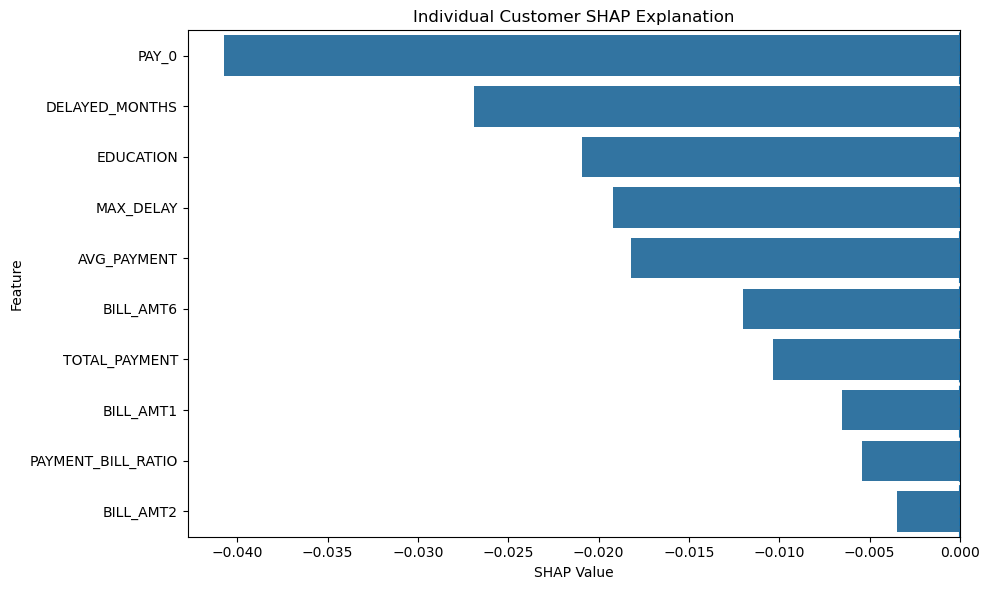

In [86]:
# Display the strongest factors affecting this customer's prediction

top_customer_factors = customer_explanation.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customer_factors,
    x="SHAP_Value",
    y="Feature"
)

plt.axvline(0, linestyle="--")

plt.title("Individual Customer SHAP Explanation")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [87]:
# What-If Credit Risk Simulator

def predict_probability(customer_features):
    customer_df = pd.DataFrame(
        [customer_features],
        columns=X.columns
    )

    customer_scaled = scaler.transform(customer_df)

    probability = model_weighted.predict(
        customer_scaled,
        verbose=0
    )[0][0]

    return probability


# Select a test customer
customer = X_test.iloc[0].copy()

# Current risk
current_probability = predict_probability(customer.values)

# Create a scenario
scenario_customer = customer.copy()

# Reduce average bill by 20%
scenario_customer["AVG_BILL"] *= 0.80

# Recalculate credit utilization
scenario_customer["CREDIT_UTILIZATION"] = (
    scenario_customer["AVG_BILL"] /
    scenario_customer["LIMIT_BAL"]
)

# New risk
scenario_probability = predict_probability(
    scenario_customer.values
)

print("Current Default Probability:",
      round(current_probability * 100, 2), "%")

print("Scenario Default Probability:",
      round(scenario_probability * 100, 2), "%")

Current Default Probability: 34.36 %
Scenario Default Probability: 34.32 %


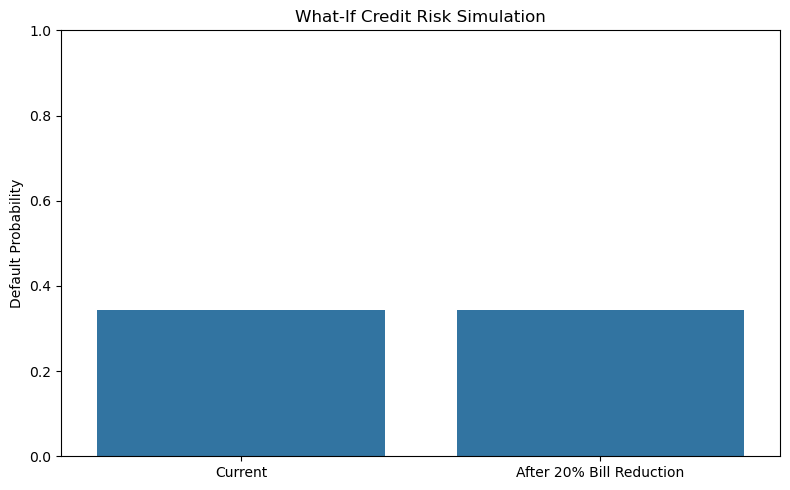

In [88]:
# Visualize the impact of the what-if scenario

comparison = pd.DataFrame({
    "Scenario": ["Current", "After 20% Bill Reduction"],
    "Default_Probability": [
        current_probability,
        scenario_probability
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Scenario",
    y="Default_Probability"
)

plt.ylabel("Default Probability")
plt.xlabel("")
plt.title("What-If Credit Risk Simulation")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [89]:
# Final Model Evaluation

final_predictions = (
    y_probability_final >= best_threshold
).astype(int)

print("Final Threshold:", best_threshold)
print()

print("Classification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["No Default", "Default"],
        zero_division=0
    )
)

print("Final Accuracy:",
      round(accuracy_score(y_test, final_predictions), 4))

print("Final Precision:",
      round(precision_score(y_test, final_predictions, zero_division=0), 4))

print("Final Recall:",
      round(recall_score(y_test, final_predictions, zero_division=0), 4))

print("Final F1 Score:",
      round(f1_score(y_test, final_predictions, zero_division=0), 4))

print("Final ROC-AUC:",
      round(roc_auc_score(y_test, y_probability_final), 4))

Final Threshold: 0.55

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.84      0.86      4673
     Default       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

Final Accuracy: 0.7787
Final Precision: 0.4997
Final Recall: 0.5652
Final F1 Score: 0.5304
Final ROC-AUC: 0.769


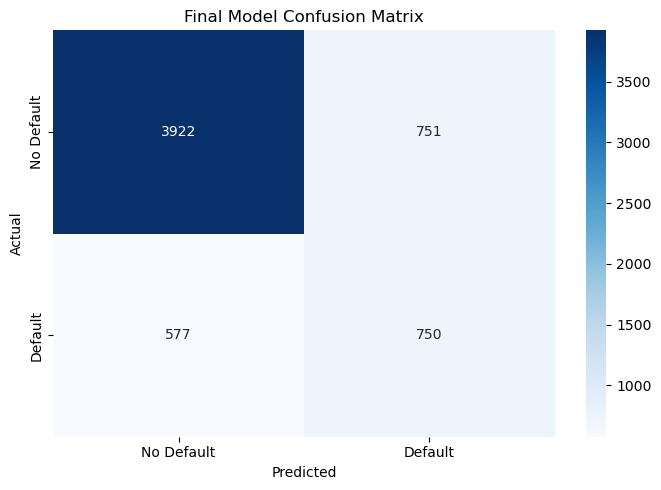

In [90]:
# Final Confusion Matrix

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

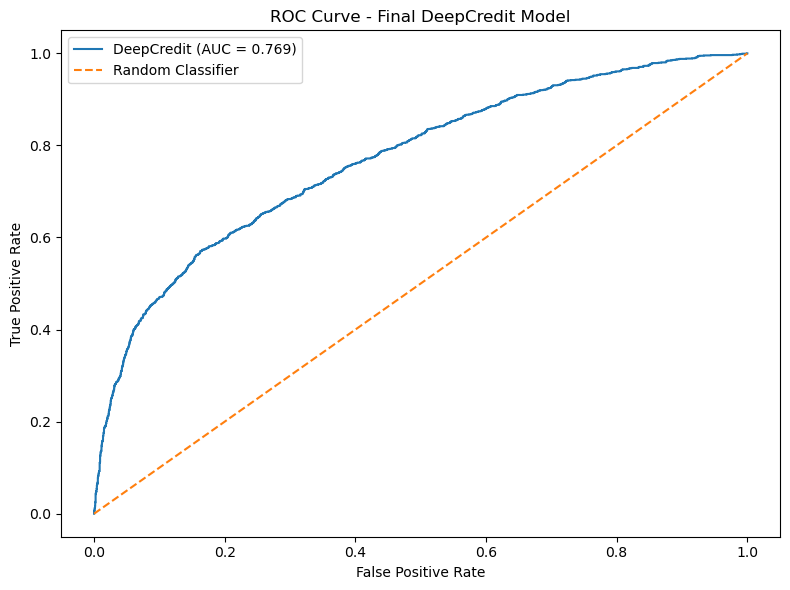

In [91]:
# ROC Curve for the Final Model

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability_final
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"DeepCredit (AUC = {roc_auc_score(y_test, y_probability_final):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final DeepCredit Model")
plt.legend()

plt.tight_layout()
plt.show()

In [92]:
# Save the trained DeepCredit model

model_weighted.save("DeepCredit_model.keras")

print("Model saved successfully as: DeepCredit_model.keras")

Model saved successfully as: DeepCredit_model.keras


In [93]:
# Save the scaler used for preprocessing

import joblib

joblib.dump(scaler, "DeepCredit_scaler.pkl")

print("Scaler saved successfully as: DeepCredit_scaler.pkl")

Scaler saved successfully as: DeepCredit_scaler.pkl


In [94]:
# DeepCredit Final Results Summary

final_auc = roc_auc_score(y_test, y_probability_final)
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions, zero_division=0)
final_recall = recall_score(y_test, final_predictions, zero_division=0)
final_f1 = f1_score(y_test, final_predictions, zero_division=0)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Decision Threshold"
    ],
    "Value": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc,
        best_threshold
    ]
})

final_results["Value"] = final_results["Value"].round(4)

final_results

,Metric,Value
0,Accuracy,0.7787
1,Precision,0.4997
2,Recall,0.5652
3,F1 Score,0.5304
4,ROC-AUC,0.7690
5,Decision Threshold,0.5500


In [95]:
# Key Findings

print("KEY FINDINGS")
print("-" * 50)

print("1. Repayment behavior was among the strongest predictors of default.")
print("2. Credit utilization provided additional information about customer risk.")
print("3. Class weighting was used to improve the model's handling of default cases.")
print("4. SHAP was used to explain which features influenced individual predictions.")
print("5. The What-If Simulator demonstrates how changing financial behavior can alter predicted risk.")
print("6. The final model outputs a probability of credit default for each customer.")

KEY FINDINGS
--------------------------------------------------
1. Repayment behavior was among the strongest predictors of default.
2. Credit utilization provided additional information about customer risk.
3. Class weighting was used to improve the model's handling of default cases.
4. SHAP was used to explain which features influenced individual predictions.
5. The What-If Simulator demonstrates how changing financial behavior can alter predicted risk.
6. The final model outputs a probability of credit default for each customer.


In [96]:
# Limitations and Future Improvements

print("LIMITATIONS")
print("-" * 50)

print("1. The dataset is historical and may not represent current credit behavior.")
print("2. Neural network predictions depend on the quality of the input data.")
print("3. SHAP explains model behavior but does not establish causal relationships.")
print("4. The model should not be used for real-world lending decisions without")
print("   additional validation, fairness testing, regulatory review, and human oversight.")

print("\nFUTURE IMPROVEMENTS")
print("-" * 50)

print("1. Compare the neural network with XGBoost and other machine learning models.")
print("2. Perform hyperparameter optimization.")
print("3. Add fairness and bias analysis across customer groups.")
print("4. Deploy the model through an interactive web application or API.")
print("5. Monitor model performance over time using new customer data.")

LIMITATIONS
--------------------------------------------------
1. The dataset is historical and may not represent current credit behavior.
2. Neural network predictions depend on the quality of the input data.
3. SHAP explains model behavior but does not establish causal relationships.
4. The model should not be used for real-world lending decisions without
   additional validation, fairness testing, regulatory review, and human oversight.

FUTURE IMPROVEMENTS
--------------------------------------------------
1. Compare the neural network with XGBoost and other machine learning models.
2. Perform hyperparameter optimization.
3. Add fairness and bias analysis across customer groups.
4. Deploy the model through an interactive web application or API.
5. Monitor model performance over time using new customer data.


In [97]:
# Final Project Summary

print("=" * 60)
print("DEEPCREDIT - EXPLAINABLE CREDIT RISK PREDICTION")
print("=" * 60)

print("\nMODEL")
print("Deep Neural Network using TensorFlow/Keras")

print("\nDATASET")
print(f"Customers analysed: {len(X):,}")
print(f"Features used: {X.shape[1]}")

print("\nFINAL PERFORMANCE")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")

print("\nEXPLAINABILITY")
print("SHAP-based feature importance and individual prediction explanations")

print("\nBUSINESS FEATURE")
print("What-If Credit Risk Simulator")

print("\nMODEL ARTIFACTS")
print("DeepCredit_model.keras")
print("DeepCredit_scaler.pkl")

print("\n" + "=" * 60)
print("DeepCredit pipeline completed successfully.")
print("=" * 60)

DEEPCREDIT - EXPLAINABLE CREDIT RISK PREDICTION

MODEL
Deep Neural Network using TensorFlow/Keras

DATASET
Customers analysed: 30,000
Features used: 32

FINAL PERFORMANCE
Accuracy  : 0.7787
Precision : 0.4997
Recall    : 0.5652
F1 Score  : 0.5304
ROC-AUC   : 0.7690

EXPLAINABILITY
SHAP-based feature importance and individual prediction explanations

BUSINESS FEATURE
What-If Credit Risk Simulator

MODEL ARTIFACTS
DeepCredit_model.keras
DeepCredit_scaler.pkl

DeepCredit pipeline completed successfully.


In [98]:
# Check that all important DeepCredit files were created

import os

files_to_check = [
    "DeepCredit_model.keras",
    "DeepCredit_scaler.pkl"
]

for file_name in files_to_check:
    if os.path.exists(file_name):
        print(f"✓ {file_name} created successfully")
    else:
        print(f"✗ {file_name} not found")

✓ DeepCredit_model.keras created successfully
✓ DeepCredit_scaler.pkl created successfully


In [99]:
# Final DeepCredit Notebook Completion Check

print("=" * 60)
print("DEEP CREDIT PROJECT - COMPLETION CHECK")
print("=" * 60)

checks = {
    "Dataset loaded": X.shape[0] > 0,
    "Features prepared": X.shape[1] > 0,
    "Training completed": len(history_weighted.history["loss"]) > 0,
    "SHAP analysis completed": len(feature_importance) > 0,
    "What-if simulator completed": "scenario_probability" in globals(),
    "Final evaluation completed": "final_auc" in globals(),
    "Model saved": os.path.exists("DeepCredit_model.keras"),
    "Scaler saved": os.path.exists("DeepCredit_scaler.pkl")
}

for check, status in checks.items():
    print(f"{'✓' if status else '✗'} {check}")

print("=" * 60)

if all(checks.values()):
    print("🎉 DEEPCREDIT PROJECT COMPLETED SUCCESSFULLY!")
else:
    print("⚠️ Some steps need to be checked.")

DEEP CREDIT PROJECT - COMPLETION CHECK
✓ Dataset loaded
✓ Features prepared
✓ Training completed
✓ SHAP analysis completed
✓ What-if simulator completed
✓ Final evaluation completed
✓ Model saved
✓ Scaler saved
🎉 DEEPCREDIT PROJECT COMPLETED SUCCESSFULLY!


In [100]:
# Final notebook conclusion

print("""
DEEPCREDIT — PROJECT CONCLUSION
--------------------------------

DeepCredit demonstrates how deep learning can be applied to
credit default prediction using customer financial data.

The project combines:
• Data analysis and feature engineering
• TensorFlow/Keras deep learning
• Class imbalance handling
• Threshold optimization
• SHAP Explainable AI
• What-If credit risk simulation

The model produces a probability-based estimate of credit
default risk and provides explanations for its predictions.

This project is intended for educational and portfolio use.
Real-world credit decisions would require additional validation,
fairness testing, regulatory compliance, privacy protection,
and human oversight.
""")


DEEPCREDIT — PROJECT CONCLUSION
--------------------------------

DeepCredit demonstrates how deep learning can be applied to
credit default prediction using customer financial data.

The project combines:
• Data analysis and feature engineering
• TensorFlow/Keras deep learning
• Class imbalance handling
• Threshold optimization
• SHAP Explainable AI
• What-If credit risk simulation

The model produces a probability-based estimate of credit
default risk and provides explanations for its predictions.

This project is intended for educational and portfolio use.
Real-world credit decisions would require additional validation,
fairness testing, regulatory compliance, privacy protection,
and human oversight.

